In [1]:
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'benchmark').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.config import FIGURE_DIR, TrainingConfig
from benchmark.examples.diffusion.results.summary_dimension_comparison import (
    LOSS_VARIANTS,
    NO_MMD_SUMMARY_SPECS,
    generate_log10_logml_diagnostic_loess_grid,
    generate_pmp_diagnostic_loess_grid,
    generate_posterior_mmd_diagnostic_loess_grid,
    generate_s4d_diagnostic_gold_pmp_grid,
)

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
RERUN_SUFFIX = 'noMMD_rerun1'
RERUN_VARIANT = 'without_mmd_rerun1'
RERUN_SUMMARY_SPECS = tuple(
    (
        label,
        TrainingConfig(
            summary_multiplier=config.summary_multiplier,
            summary_base_distribution=None,
            run_suffix=RERUN_SUFFIX,
        ),
    )
    for label, config in NO_MMD_SUMMARY_SPECS
)
LOSS_VARIANTS[RERUN_VARIANT] = (
    'Without MMD loss (rerun1)',
    RERUN_SUMMARY_SPECS,
)

OUTPUT_ROOT = FIGURE_DIR / 's4d_diagnostic_comparison_rerun1'


## Empirical PMP error: S=4D across four diagnostics

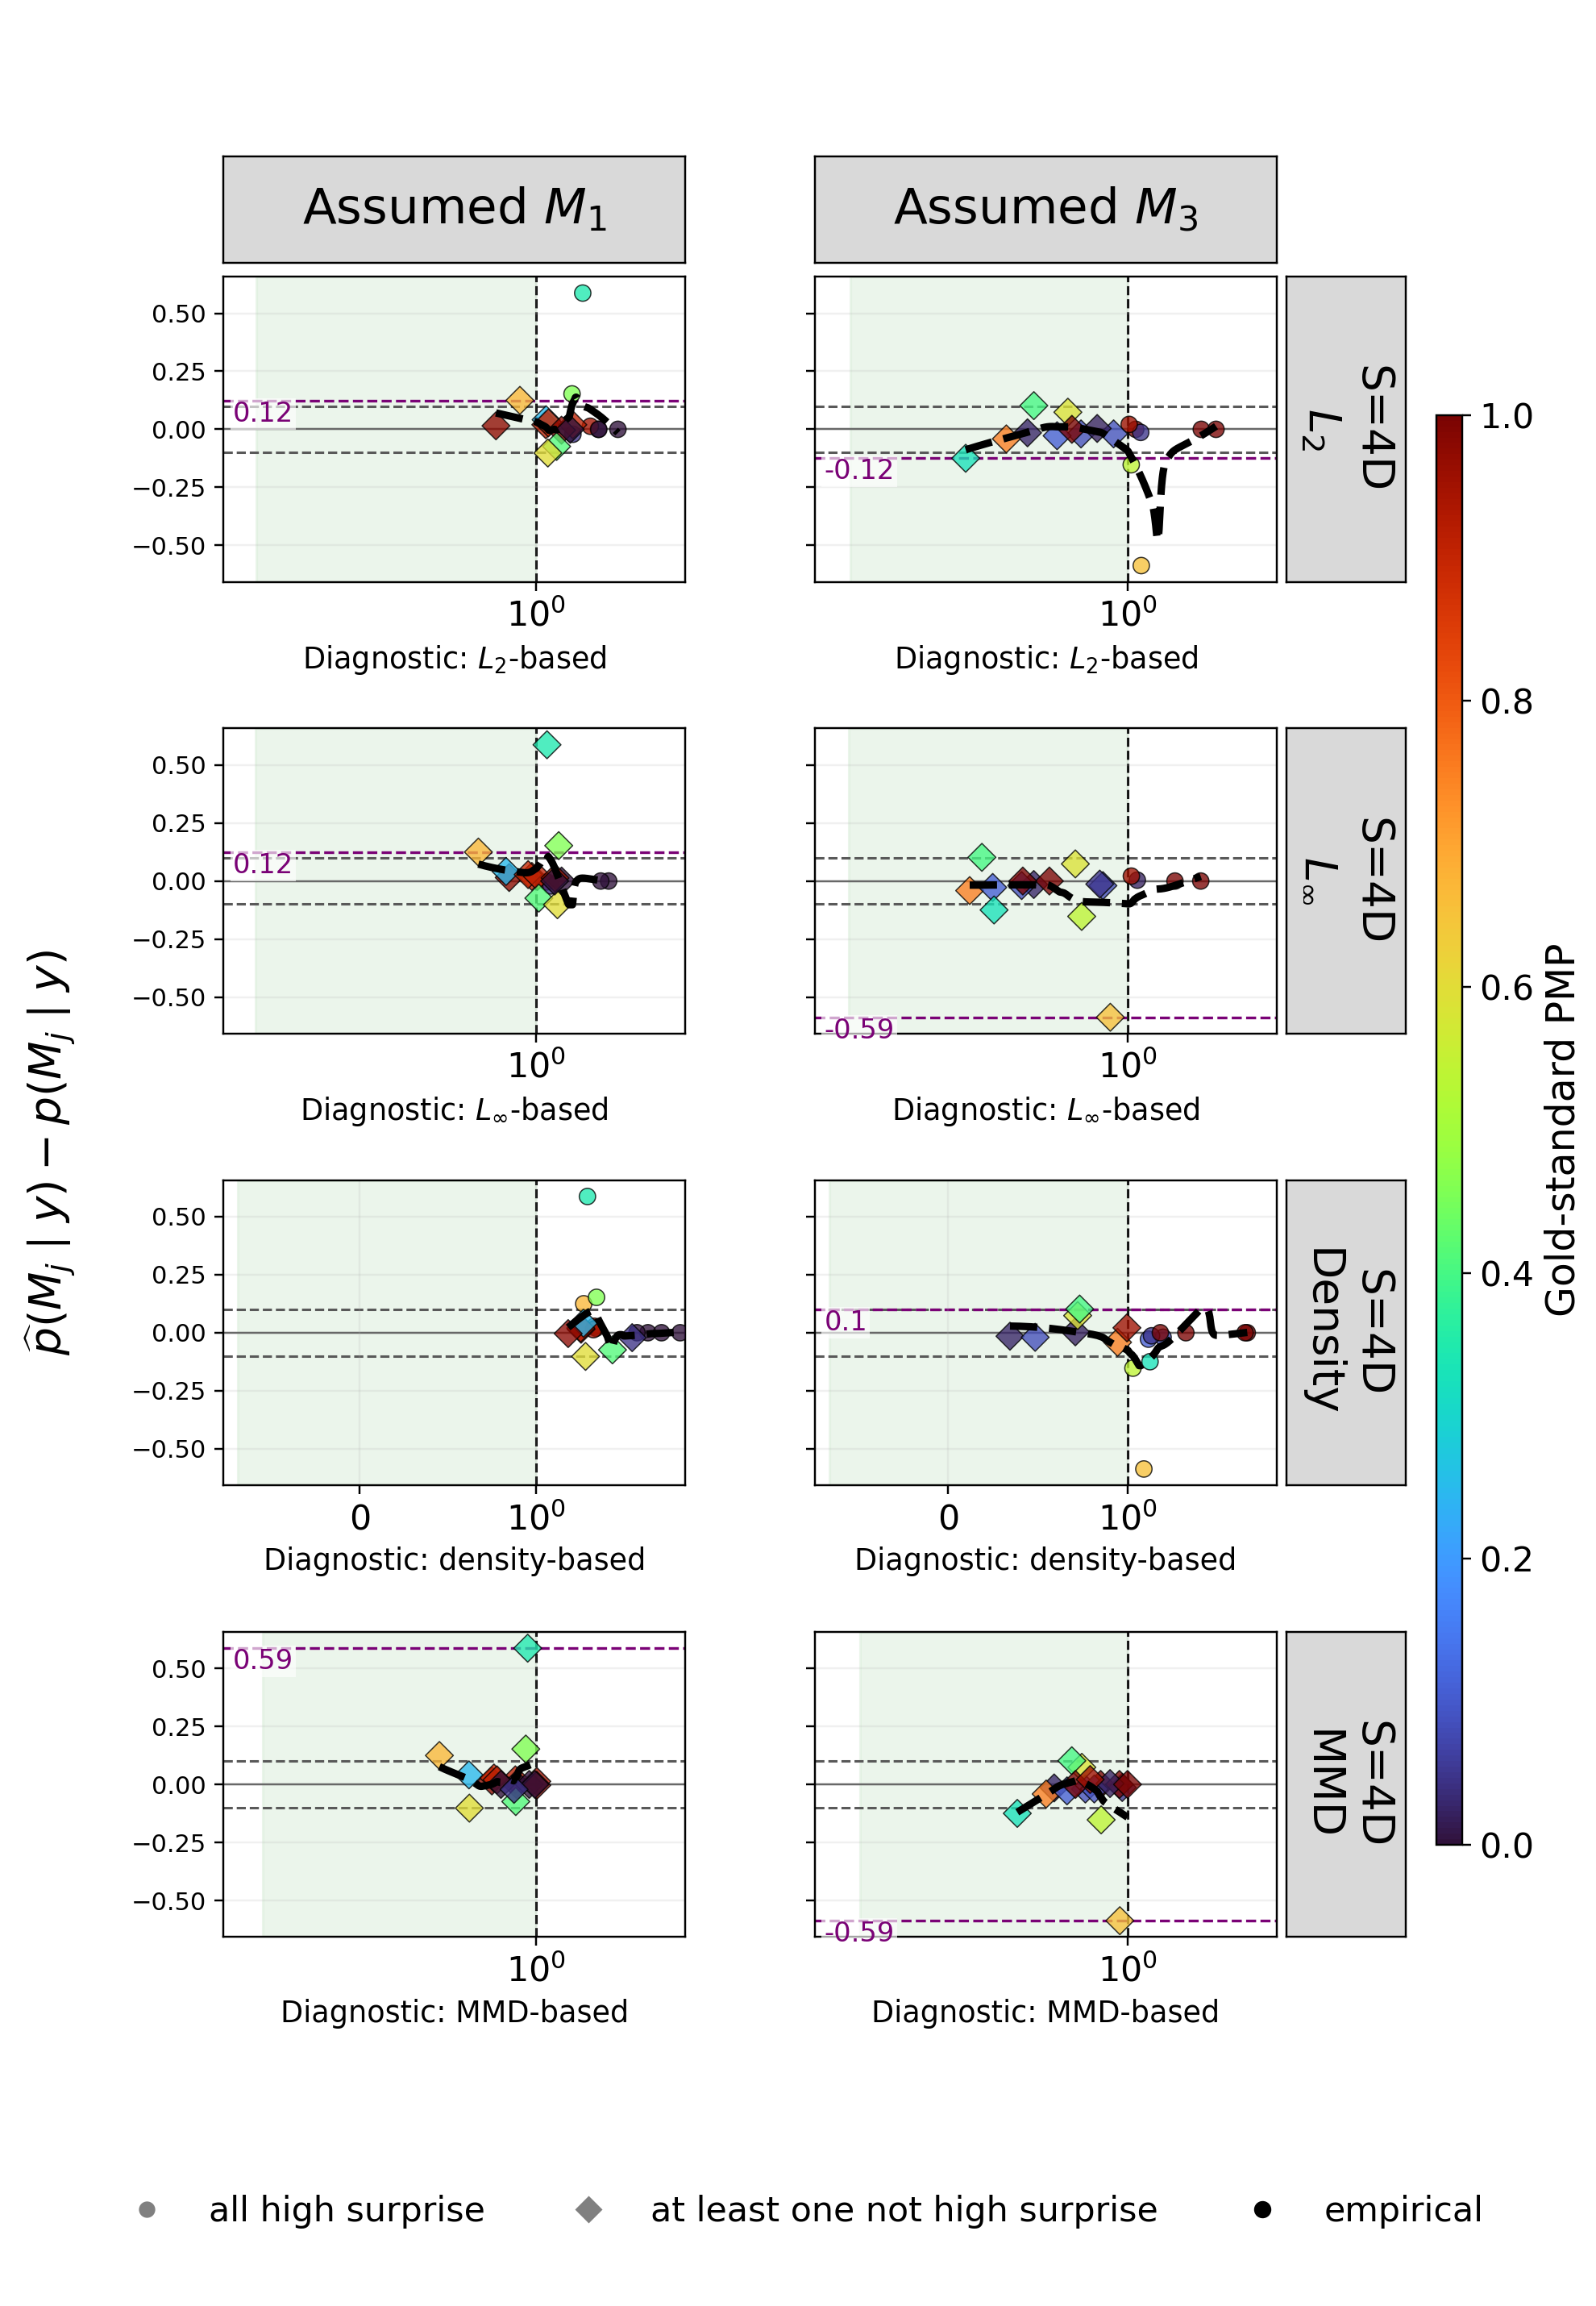

In [3]:
s4d_grid = generate_s4d_diagnostic_gold_pmp_grid(
    loss_variant=RERUN_VARIANT,
    output_root=OUTPUT_ROOT,
    gold_pmp_cmap='turbo',
    show_max_error=True,
)

display(Markdown('## Empirical PMP error: S=4D across four diagnostics'))
display(Image(filename=str(s4d_grid['png']), width=800))

## Empirical base-10 log marginal-likelihood error across four diagnostics

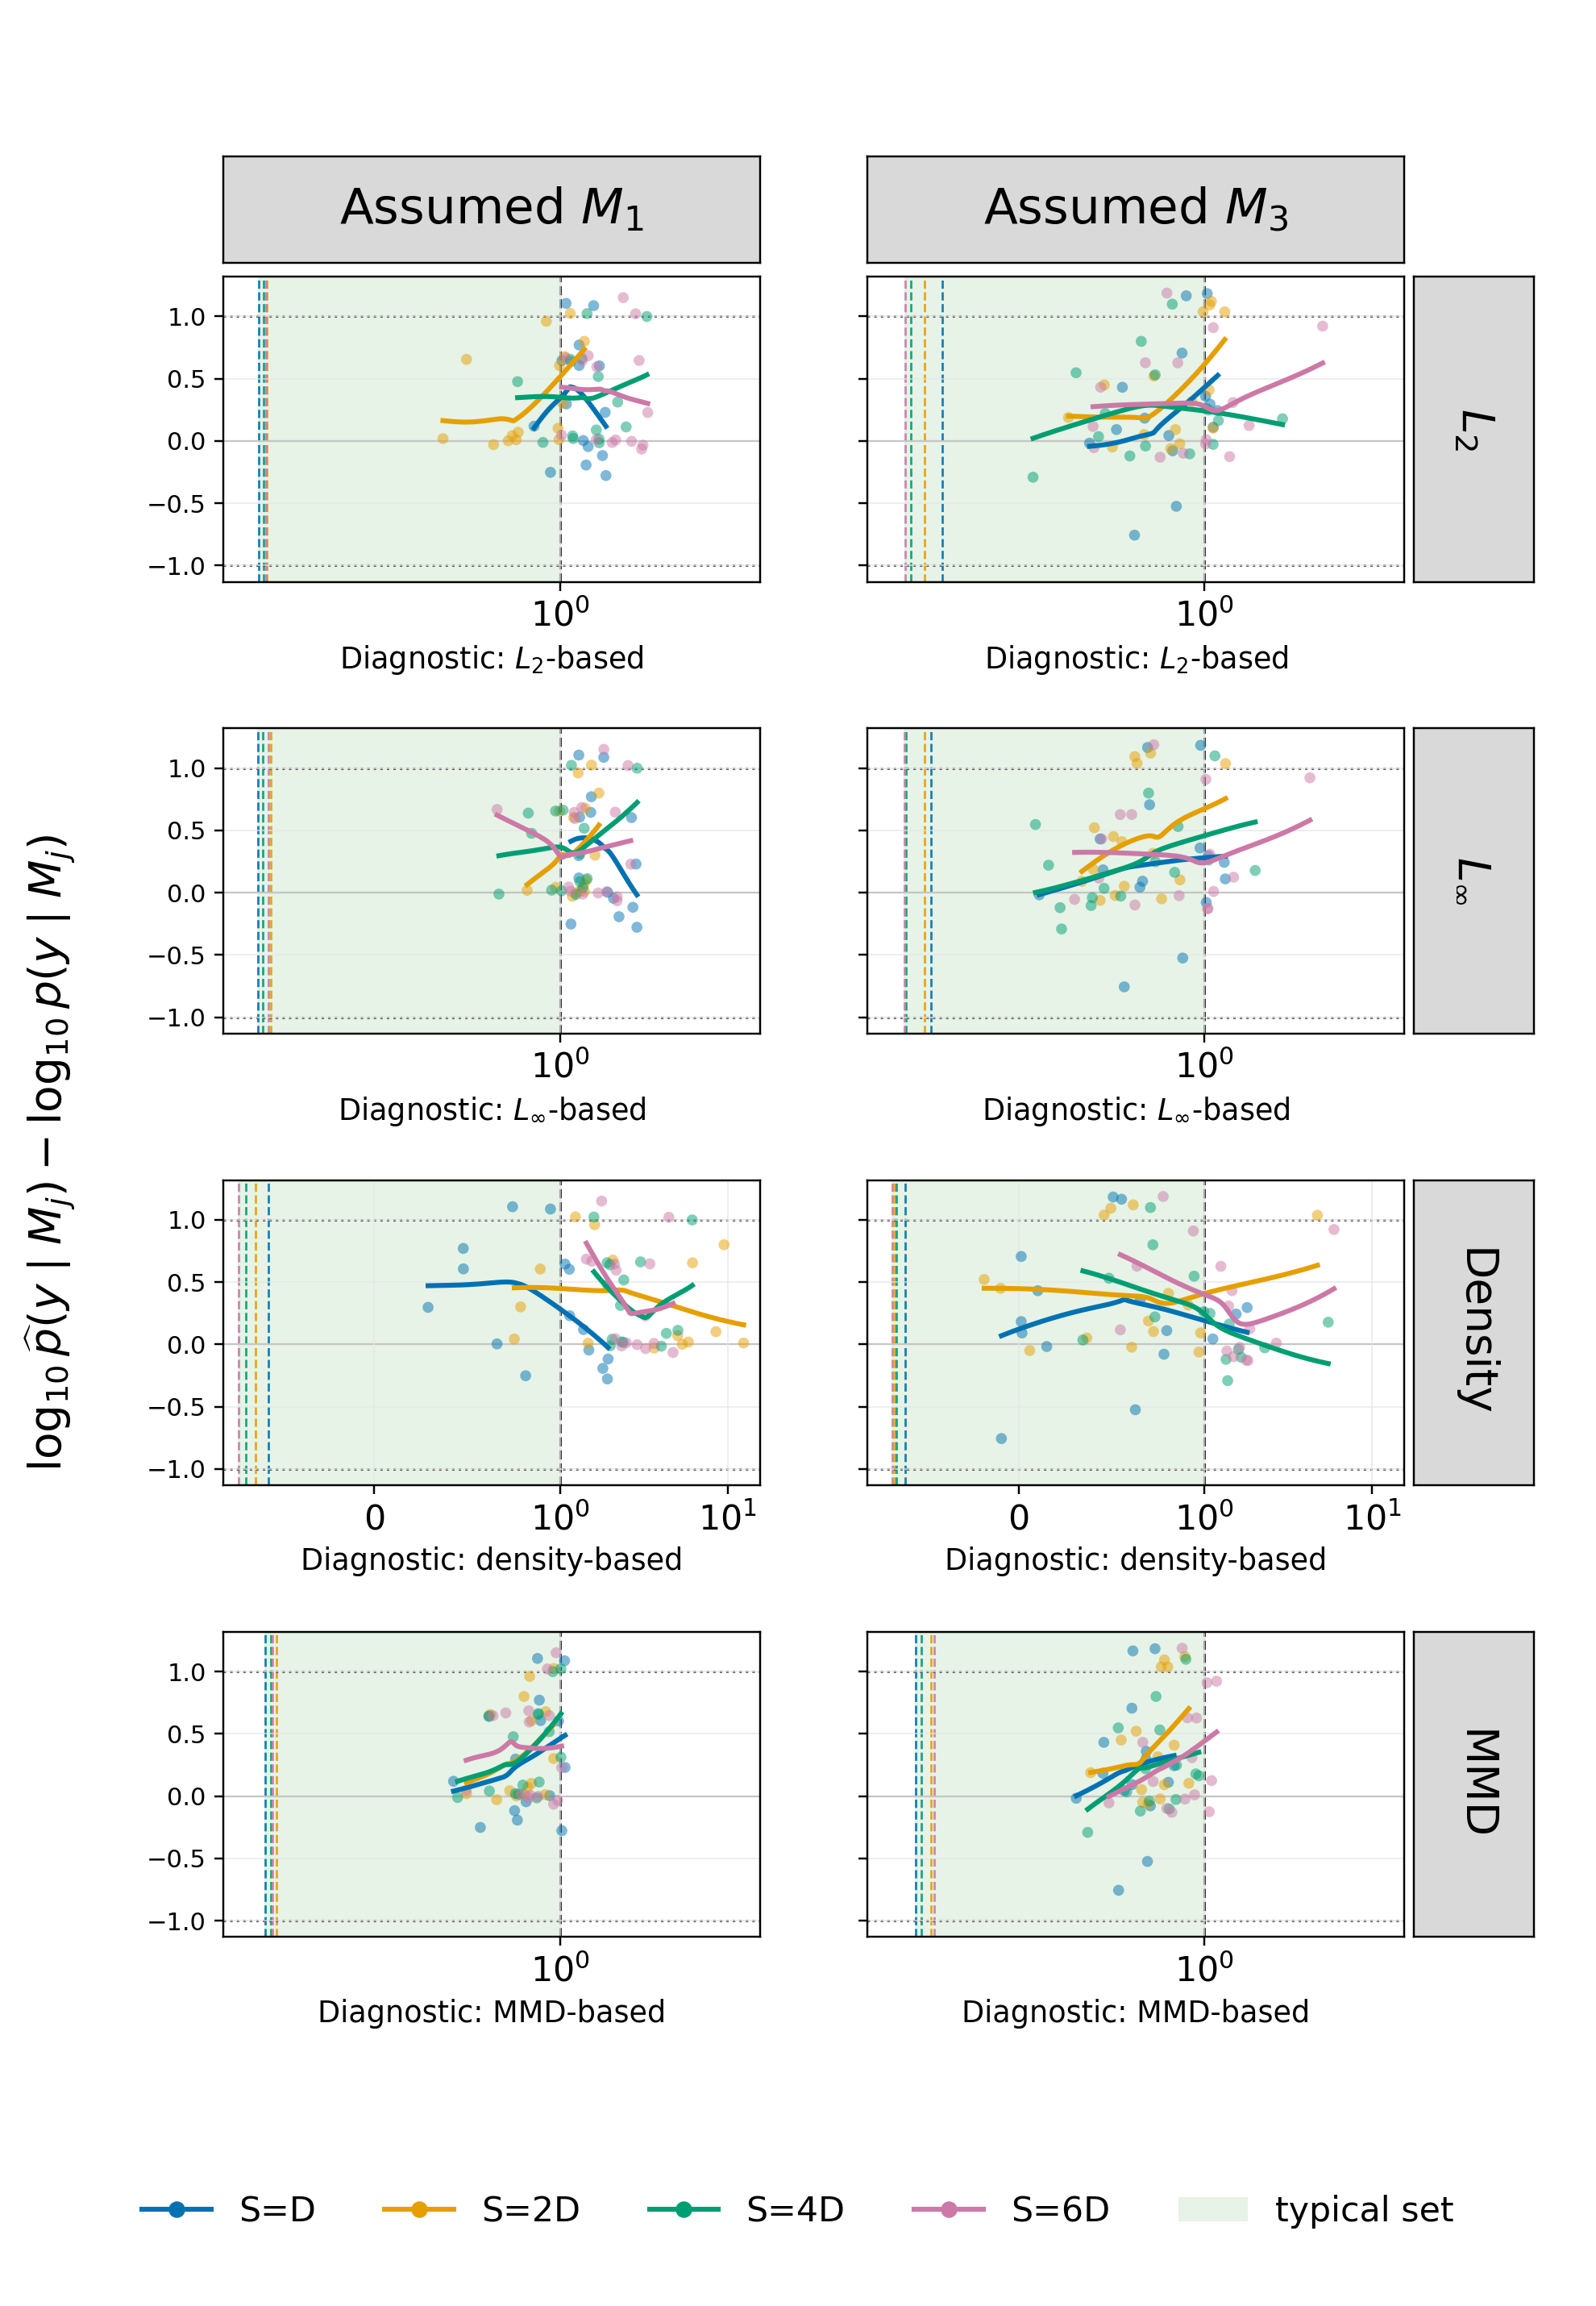

In [4]:
log10_logml_grid = generate_log10_logml_diagnostic_loess_grid(
    loss_variant=RERUN_VARIANT,
    output_root=OUTPUT_ROOT,
)

display(Markdown('## Empirical base-10 log marginal-likelihood error across four diagnostics'))
display(Image(filename=str(log10_logml_grid['png']), width=800))

## Empirical signed PMP error across four diagnostics

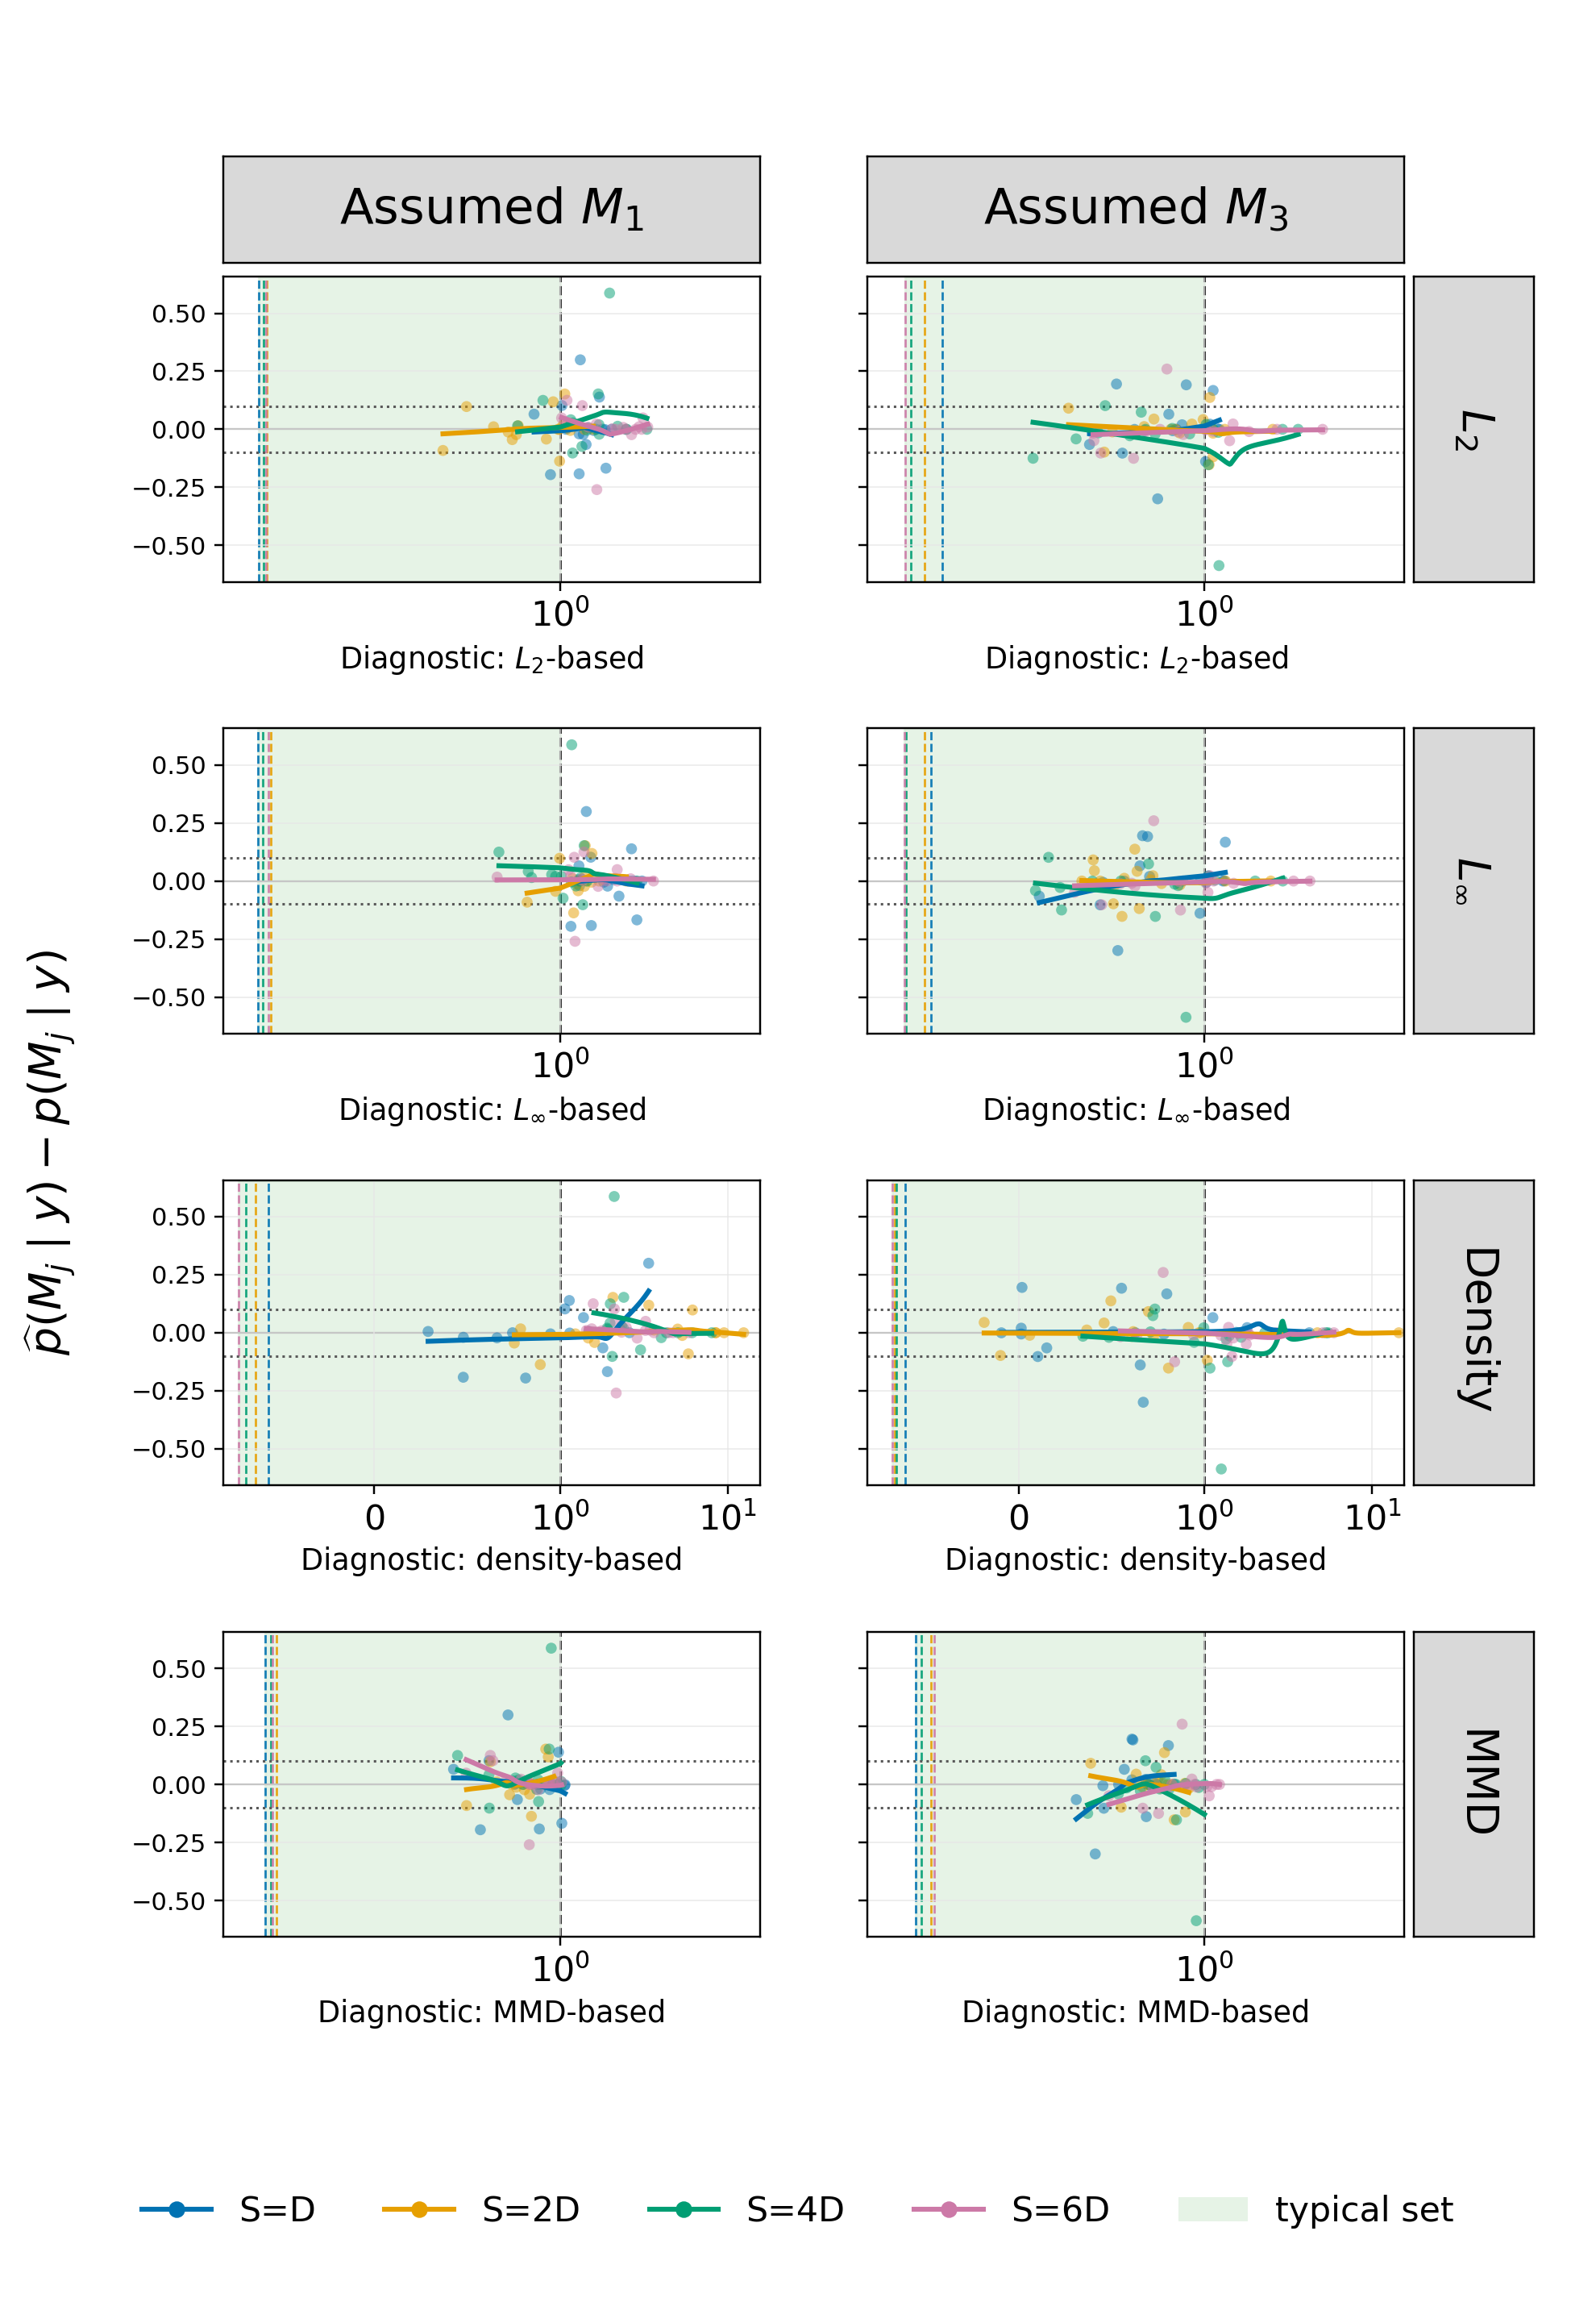

In [5]:
pmp_error_grid = generate_pmp_diagnostic_loess_grid(
    loss_variant=RERUN_VARIANT,
    output_root=OUTPUT_ROOT,
)

display(Markdown('## Empirical signed PMP error across four diagnostics'))
display(Image(filename=str(pmp_error_grid['png']), width=800))

## Empirical posterior MMD z-score across four diagnostics

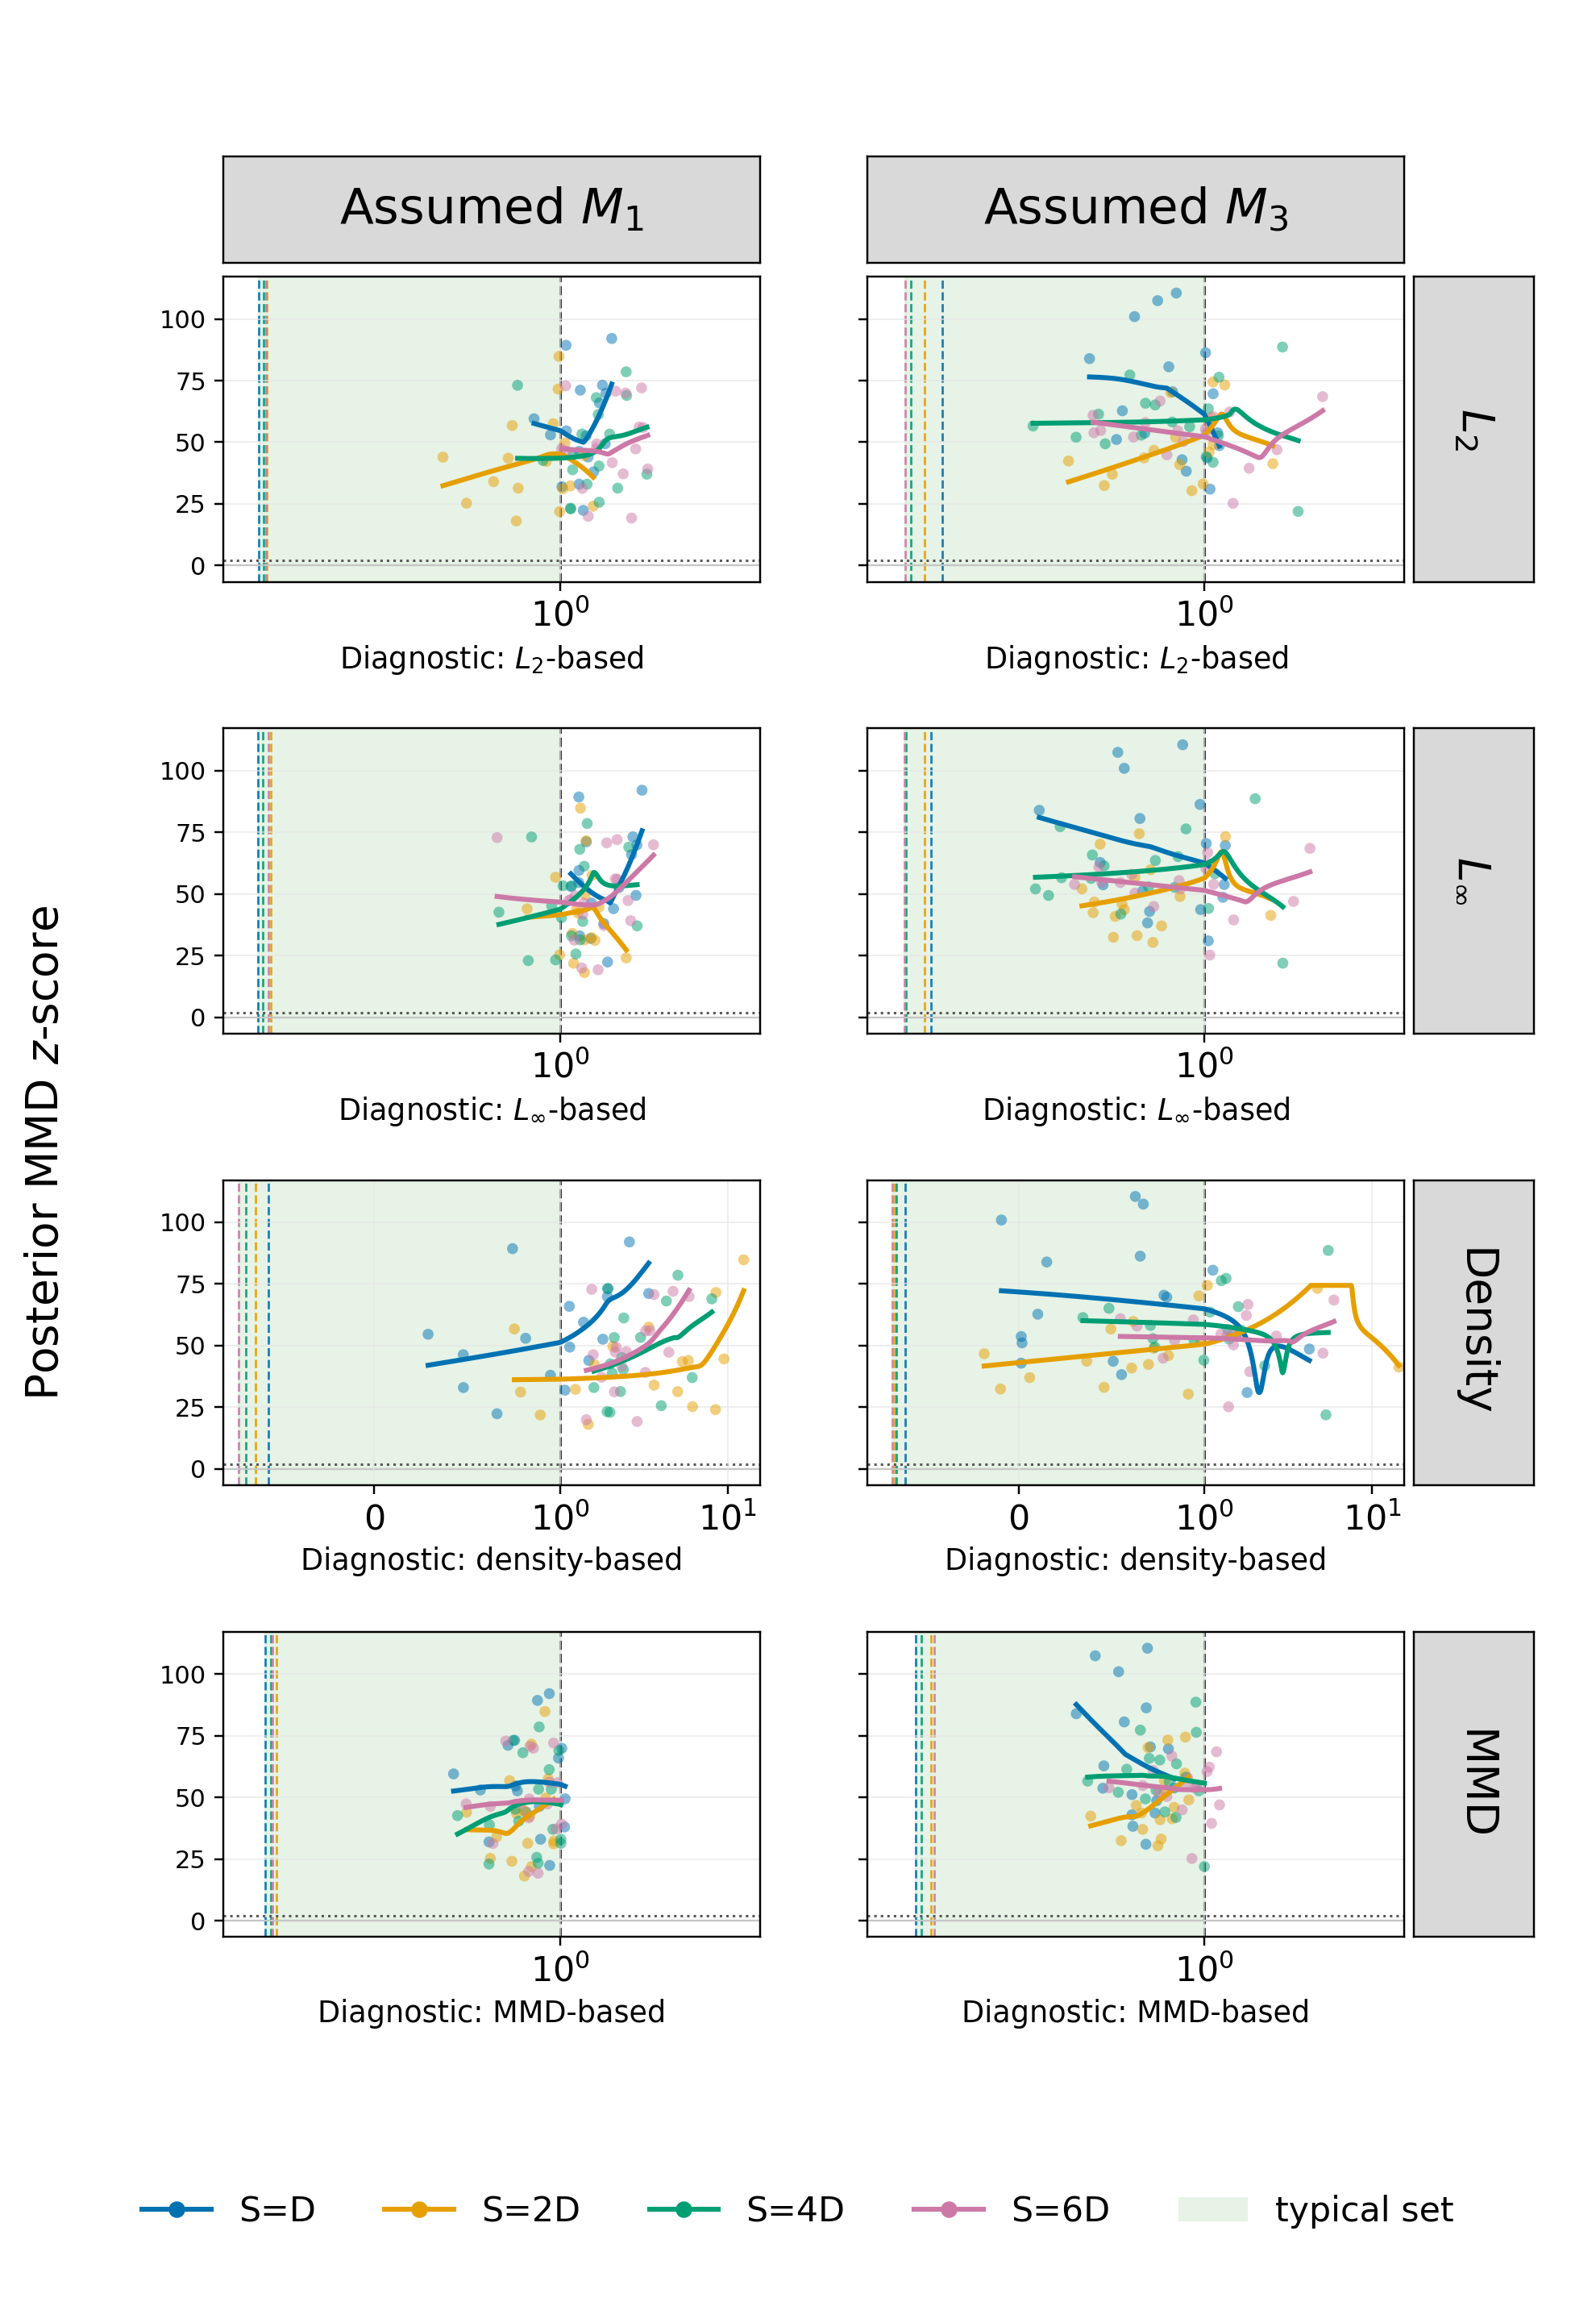

In [6]:
posterior_mmd_grid = generate_posterior_mmd_diagnostic_loess_grid(
    loss_variant=RERUN_VARIANT,
    output_root=OUTPUT_ROOT,
)

display(Markdown('## Empirical posterior MMD z-score across four diagnostics'))
display(Image(filename=str(posterior_mmd_grid['png']), width=800))